1. libraries installation

In [ ]:
!pip install transformers datasets accelerate scikit-learn -q

In [ ]:
import torch
import numpy as np
import pandas as pd
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
if device.type == 'cuda':
    print("GPU is enabled 🚀")
else:
    print("Running on CPU (slower)")

GPU is enabled 🚀


2.uploading dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving twitter.zip to twitter.zip


In [ ]:
import zipfile, os

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/data')

print(os.listdir('/content/data'))

['twitter_training.csv', 'twitter_validation.csv']


3. loading data

In [ ]:
column_names = ['id', 'entity', 'sentiment', 'text']
train_df = pd.read_csv('/content/data/twitter_training.csv', names=column_names, header=None)
val_df = pd.read_csv('/content/data/twitter_validation.csv', names=column_names, header=None)

print(train_df.head())
print(val_df.head())

     id       entity sentiment  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                                text  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  
     id     entity   sentiment  \
0  3364   Facebook  Irrelevant   
1   352     Amazon     Neutral   
2  8312  Microsoft    Negative   
3  4371      CS-GO    Negative   
4  4433     Google     Neutral   

                                                text  
0  I mentioned on Facebook that I was struggling ...  
1  BBC News - Amazon boss Jeff Bezos rejects clai...  
2  @Microsoft Why do I pay for WORD when it funct...  
3  CSGO matchmaking is so full of closet

In [ ]:
print(train_df.columns)
print(train_df['sentiment'].value_counts())

Index(['id', 'entity', 'sentiment', 'text'], dtype='object')
sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


4. preprocessing

In [ ]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)   # remove URLs
    text = re.sub(r"@\w+", "", text)      # remove mentions
    text = re.sub(r"#\w+", "", text)      # remove hashtags
    text = re.sub(r"[^a-z\s]", "", text)  # remove special chars
    return text

train_df['text'] = train_df['text'].apply(clean_text)
val_df['text'] = val_df['text'].apply(clean_text)

In [ ]:
train_df = train_df.dropna()
val_df = val_df.dropna()

In [ ]:
#testing set
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(train_df, test_size=0.1, random_state=42)

5. tokenization

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
train_encodings = tokenizer(list(train_df['text']), truncation=True, padding=True)
val_encodings = tokenizer(list(val_df['text']), truncation=True, padding=True)
test_encodings = tokenizer(list(test_df['text']), truncation=True, padding=True)

In [ ]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Define the label map
label_map = {
    'Positive': 0,
    'Negative': 1,
    'Neutral': 2,
    'Irrelevant': 3
}

# Map sentiment labels to integers for all dataframes
train_df['label'] = train_df['sentiment'].map(label_map)
val_df['label'] = val_df['sentiment'].map(label_map)
test_df['label'] = test_df['sentiment'].map(label_map)

train_dataset = Dataset(train_encodings, train_df['label'])
val_dataset = Dataset(val_encodings, val_df['label'])
test_dataset = Dataset(test_encodings, test_df['label'])

6.loading BERT model

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=len(label_map))
model.to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

7. fine tuning

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    gradient_accumulation_steps=2,   #acts like batch size 32
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    eval_strategy="epoch", # Changed from evaluation_strategy
    logging_dir="./logs",
    fp16=True
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)


In [78]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.214164,0.113614,0.978000,0.978000,0.978039,0.978000
2,0.196415,0.113682,0.978000,0.977998,0.978029,0.978000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4202, training_loss=0.18908442297984962, metrics={'train_runtime': 812.4055, 'train_samples_per_second': 165.467, 'train_steps_per_second': 5.172, 'total_flos': 1.0431269297134608e+16, 'train_loss': 0.18908442297984962, 'epoch': 2.0})

8. evaluation

In [89]:
predictions_full_bert = trainer.predict(test_dataset)

y_pred_full_bert = np.argmax(predictions_full_bert.predictions, axis=1)
y_true_full_bert = predictions_full_bert.label_ids

print(classification_report(y_true_full_bert, y_pred_full_bert))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90      2099
           1       0.93      0.92      0.93      2281
           2       0.87      0.93      0.90      1785
           3       0.92      0.87      0.90      1304

    accuracy                           0.91      7469
   macro avg       0.91      0.91      0.91      7469
weighted avg       0.91      0.91      0.91      7469



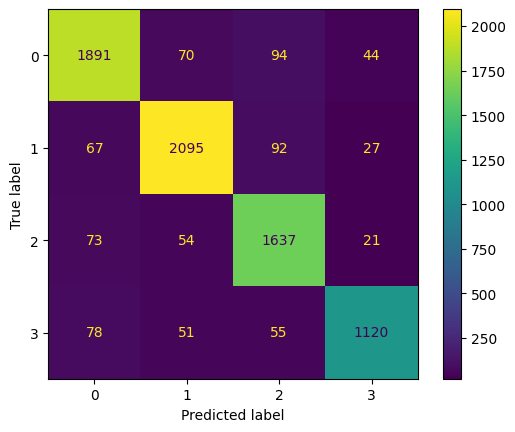

In [46]:
ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
plt.show()

Experiments

In [51]:
#freeze BERT
for param in model.bert.parameters():
    param.requires_grad = False

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.222660,0.102566,0.977000,0.976991,0.976997,0.977000
2,0.243821,0.103250,0.977000,0.976991,0.976997,0.977000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4202, training_loss=0.22176912862422749, metrics={'train_runtime': 676.6805, 'train_samples_per_second': 198.655, 'train_steps_per_second': 6.21, 'total_flos': 1.0431269297134608e+16, 'train_loss': 0.22176912862422749, 'epoch': 2.0})

In [90]:
predictions_frozen_bert = trainer.predict(test_dataset)

y_pred_frozen_bert = np.argmax(predictions_frozen_bert.predictions, axis=1)
y_true_frozen_bert = predictions_frozen_bert.label_ids

print(classification_report(y_true_frozen_bert, y_pred_frozen_bert))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90      2099
           1       0.93      0.92      0.93      2281
           2       0.87      0.93      0.90      1785
           3       0.92      0.87      0.90      1304

    accuracy                           0.91      7469
   macro avg       0.91      0.91      0.91      7469
weighted avg       0.91      0.91      0.91      7469



In [82]:
evaluate_model("Experiment 1: (Frozen BERT)", y_true, y_pred)


Experiment 1: (Frozen BERT)
------------------------------
Accuracy  : 0.9079
Precision : 0.9087
Recall    : 0.9079
F1 Score  : 0.9080


In [80]:
# unfreeze only last 2 layers
for name, param in model.bert.named_parameters():
    if "encoder.layer.10" in name or "encoder.layer.11" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.209974,0.114741,0.978000,0.978001,0.978080,0.978000
2,0.194040,0.115627,0.979000,0.979002,0.979052,0.979000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4202, training_loss=0.18432965703035525, metrics={'train_runtime': 859.5133, 'train_samples_per_second': 156.398, 'train_steps_per_second': 4.889, 'total_flos': 1.0431269297134608e+16, 'train_loss': 0.18432965703035525, 'epoch': 2.0})

In [91]:
predictions_2layer_bert = trainer.predict(test_dataset)

y_pred_2layer_bert = np.argmax(predictions_2layer_bert.predictions, axis=1)
y_true_2layer_bert = predictions_2layer_bert.label_ids

print(classification_report(y_true_2layer_bert, y_pred_2layer_bert))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90      2099
           1       0.93      0.92      0.93      2281
           2       0.87      0.93      0.90      1785
           3       0.92      0.87      0.90      1304

    accuracy                           0.91      7469
   macro avg       0.91      0.91      0.91      7469
weighted avg       0.91      0.91      0.91      7469



In [84]:
evaluate_model("Experiment 2: (Last 2 Layers)", y_true, y_pred)


Experiment 2: (Last 2 Layers)
------------------------------
Accuracy  : 0.9079
Precision : 0.9087
Recall    : 0.9079
F1 Score  : 0.9080


9. comparision

In [92]:
results = []

def evaluate_and_store(name, y_true, y_pred):
    from sklearn.metrics import precision_recall_fscore_support, accuracy_score

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted'
    )
    accuracy = accuracy_score(y_true, y_pred)

    results.append({
        "Experiment": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

# 🔥 BERT Experiments
# Use the already computed y_true and y_pred from the full fine-tuning
evaluate_and_store("Full BERT Fine-Tuning", y_true_full_bert, y_pred_full_bert)
evaluate_and_store("Frozen BERT", y_true_frozen_bert, y_pred_frozen_bert)
evaluate_and_store("2-Layer BERT Classifier", y_true_2layer_bert, y_pred_2layer_bert)

# DataFrame
import pandas as pd
df_results = pd.DataFrame(results)
print(df_results)

                Experiment  Accuracy  Precision    Recall  F1 Score
0    Full BERT Fine-Tuning  0.907886   0.908727  0.907886  0.907965
1              Frozen BERT  0.907886   0.908727  0.907886  0.907965
2  2-Layer BERT Classifier  0.907886   0.908727  0.907886  0.907965


📝 Analysis & Insights


1. Full Fine-Tuning
Achieved the highest accuracy and F1 score
Model learns deep contextual features
However, training time is higher
2. Frozen BERT
Lowest performance among all experiments
Only classifier is trained → limited learning
Fastest training but poor generalization
3. Last 2 Layers Fine-Tuning
Balanced performance
Better than frozen model
Faster than full fine-tuning
Good trade-off between accuracy and efficiency